#  Visual Question Answering — Món Ăn Việt Nam
## Hướng B2: Fine-tune PaliGemma với LoRA/PEFT

Notebook này thực hiện **fine-tune PaliGemma-3B** trên dataset món ăn Việt Nam sử dụng **LoRA (Low-Rank Adaptation)** để giảm chi phí tính toán, sau đó đánh giá kết quả trên tập test.

---

###  Tổng quan thí nghiệm

| Thành phần | Chi tiết |
|---|---|
| **Model gốc** | `google/paligemma-3b-mix-224` |
| **Phương pháp fine-tune** | LoRA (PEFT) |
| **LoRA rank (r)** | 16 |
| **LoRA alpha** | 32 |
| **Target modules** | q_proj, v_proj, k_proj, o_proj |
| **Trainable params** | 6,672,384 / 2,930,138,864 (0.23%) |
| **Quantization** | 4-bit NF4 (bitsandbytes) |
| **Optimizer** | AdamW 8-bit |
| **Learning rate** | 2e-4 (cosine schedule) |
| **Batch size hiệu dụng** | 8 (batch=2 × accum=4) |
| **Train size** | 5,000 mẫu |
| **Val size** | 554 mẫu |
| **Epochs** | 2 |
| **GPU** | Tesla T4 (15.6 GB) |

---

### 🌐 Chiến lược xử lý tiếng Việt

PaliGemma được pretrain trên **WebLI** — dataset đa ngôn ngữ bao gồm tiếng Việt — nên toàn bộ pipeline sử dụng tiếng Việt **trực tiếp** mà không qua dịch máy:

##  1. Cài đặt thư viện

In [1]:
!pip install -q -U transformers>=4.41 accelerate bitsandbytes datasets \
                deep-translator rouge-score bert-score nltk peft \
                'Pillow<11.0.0'

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


##  2. Import thư viện & kiểm tra GPU

In [2]:
import torch, time, os, requests, random, shutil, numpy as np, re
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from transformers import (
    PaliGemmaProcessor, PaliGemmaForConditionalGeneration,
    BitsAndBytesConfig, get_cosine_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import bitsandbytes as bnb
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import pandas as pd

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Torch: {torch.__version__}')

GPU  : Tesla T4
VRAM : 15.6 GB
Torch: 2.10.0+cu128


##  3. Load Dataset

Dataset: [`dung3008/vqa-food-vietnamese`](https://huggingface.co/datasets/dung3008/vqa-food-vietnamese)

In [3]:
dataset   = load_dataset('dung3008/vqa-food-vietnamese')
test_data = dataset['test']
print(f'Train: {len(dataset["train"])} | Val: {len(dataset["validation"])} | Test: {len(test_data)}')
print(f'Sample: {test_data[0]}')

README.md:   0%|          | 0.00/673 [00:00<?, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/12810 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/554 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/584 [00:00<?, ? examples/s]

Train: 12810 | Val: 554 | Test: 584
Sample: {'question': 'trong ảnh là món ăn gì', 'answer': 'bánh bèo', 'question_type': 'recognition', 'answer_type': 'text', 'image_path': 'test/Banh_Beo/69.jpg', 'dish': 'Banh_Beo'}


In [5]:
HF_BASE_URL = 'https://huggingface.co/datasets/dung3008/vqa-food-vietnamese/resolve/main/images'
image_cache = {}

def load_image_from_hf(image_path: str) -> Image.Image:
    if image_path in image_cache:
        return image_cache[image_path]
    url = f'{HF_BASE_URL}/{image_path}'
    response = requests.get(url, timeout=15)
    if response.status_code != 200:
        raise ValueError(f'Cannot load: {url} ({response.status_code})')
    img = Image.open(BytesIO(response.content)).convert('RGB')
    image_cache[image_path] = img
    return img

##  5. Load Model PaliGemma (4-bit Quantization)

Model được load với **4-bit NF4 quantization** để tiết kiệm VRAM, cho phép chạy trên GPU T4.

| Tham số | Giá trị |
|---|---|
| `load_in_4bit` | True |
| `bnb_4bit_quant_type` | nf4 |
| `bnb_4bit_compute_dtype` | bfloat16 |
| `device_map` | auto |
| **VRAM sau load** | ~2.36 GB |

In [26]:
from kaggle_secrets import UserSecretsClient
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
MODEL_ID = 'google/paligemma-3b-mix-224'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print('Loading processor...')
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID, token=hf_token)

print('Loading base model (4-bit)...')
model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='cuda:0',
    token=hf_token,
    torch_dtype=torch.bfloat16,
)
print(f'Model loaded! VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Loading processor...
Loading base model (4-bit)...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

Model loaded! VRAM: 2.36 GB


##  6. Cấu hình Training

| Tham số | Giá trị | Lý do |
|---|---|---|
| `TRAIN_SIZE` | 5,000 | Cân bằng chất lượng và thời gian train |
| `EPOCHS` | 2 | Đủ để hội tụ, tránh overfitting |
| `LEARNING_RATE` | 2e-4 | Phù hợp với LoRA fine-tune |
| `ACCUM_STEPS` | 4 | Effective batch size = 8 |
| `WARMUP_STEPS` | 50 | Ổn định gradient ở đầu training |
| `patience` | 2 | Early stopping sau 2 epoch không cải thiện |

In [33]:
WORKING_DIR = '/kaggle/working/vqa_food/paligemma'
EPOCHS        = 2
LEARNING_RATE = 2e-4
WARMUP_STEPS  = 50
MAX_GRAD_NORM = 1.0
ACCUM_STEPS   = 4
TRAIN_SIZE = 5000
VAL_SIZE      = 554

os.makedirs(WORKING_DIR, exist_ok=True)

##  7. Cấu hình LoRA

LoRA chỉ train **0.23%** tổng số tham số (6.7M / 2.93B), giúp fine-tune hiệu quả trên GPU T4 mà không cần train toàn bộ model.

| Tham số LoRA | Giá trị | Ý nghĩa |
|---|---|---|
| `r` | 16 | Rank của ma trận low-rank |
| `lora_alpha` | 32 | Scaling factor (= 2×r) |
| `lora_dropout` | 0.05 | Regularization |
| `target_modules` | q_proj, v_proj, k_proj, o_proj | Các attention projection layers |
| `task_type` | CAUSAL_LM | Generative language modeling |

In [34]:
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    task_type='CAUSAL_LM',
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 6,672,384 || all params: 2,930,138,864 || trainable%: 0.2277


##  8. Chuẩn bị Dataset & DataLoader

### Normalize Answer
Trước khi dùng làm label, answer được normalize để loại bỏ các prefix thừa:

| Answer gốc | Sau normalize |
|---|---|
| `"màu chủ đạo là màu trắng"` | `"trắng"` |
| `"món ăn trong hình là bánh bèo"` | `"bánh bèo"` |
| `"nước chấm có màu vàng"` | `"vàng"` |

### Format prompt

In [ ]:
PATTERNS = [
    (r'^màu chủ đạo của .+ là (.*)',      r'\1'),
    (r'^màu sắc chủ đạo của .+ là (.*)', r'\1'),
    (r'^màu sắc chủ đạo là (.*)',         r'\1'),
    (r'^màu chủ đạo là (.*)',             r'\1'),
    (r'^màu sắc của .+ là (.*)',          r'\1'),
    (r'^món ăn trong hình là (.*)',       r'\1'),
    (r'^món ăn đang được đặt (.*)',       r'\1'),
    (r'^món ăn được đặt (.*)',            r'\1'),
    (r'^món ăn được trình bày (.*)',      r'\1'),
    (r'^món ăn có màu (.*)',              r'\1'),
    (r'^món ăn còn có màu (.*)',          r'\1'),
    (r'^nước chấm có màu (.*)',           r'\1'),
    (r'^nước chấm màu (.*)',              r'\1'),
    (r'^có màu (.*)',                     r'\1'),
    (r'^(.*) là màu chủ đạo.*',          r'\1'),
    (r'^(.*) là màu nổi bật.*',          r'\1'),
    (r'^(.*) là màu sắc chủ đạo.*',      r'\1'),
    (r'^[đd]ĩa .+ có màu (.*)',          r'\1'),
]

def normalize_answer(ans: str) -> str:
    ans = ans.strip().lower()
    for pat, repl in PATTERNS:
        if re.match(pat, ans):
            ans = re.sub(pat, repl, ans).strip()
            break
    cleaned = re.sub(r'^màu ', '', ans).strip()
    if len(cleaned.split()) <= 4:
        ans = cleaned
    return ans


random.seed(42)
train_subset = random.sample(list(dataset['train']), TRAIN_SIZE)
val_subset   = list(dataset['validation'])[:VAL_SIZE]


class VQADataset(Dataset):
    def __init__(self, data, processor):
        self.data      = data
        self.processor = processor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        try:
            image = load_image_from_hf(item['image_path'])
        except Exception:
            image = Image.new('RGB', (224, 224), color='black')

        #  PaliGemma: dùng trực tiếp tiếng Việt, không cần dịch
        question = f'Câu hỏi: {item["question"]} Trả lời:'
        answer   = normalize_answer(item['answer'])   # tiếng Việt trực tiếp
        return image, question, answer


def collate_fn(batch):
    images, questions, answers = zip(*batch)

    questions_with_image = [f'<image> {q}' for q in questions]

    inputs = processor(
        images=list(images),
        text=list(questions_with_image),
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=512,
        suffix=list(answers),   
    )

    return inputs


train_dataset = VQADataset(train_subset, processor)
val_dataset   = VQADataset(val_subset,   processor)

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True,
    collate_fn=collate_fn, num_workers=0,
)
val_loader = DataLoader(
    val_dataset, batch_size=2, shuffle=False,
    collate_fn=collate_fn, num_workers=0,
)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')
print(f'Batches/epoch: {len(train_loader)} | Effective batch: {2 * ACCUM_STEPS}')

Train: 5000 | Val: 554
Batches/epoch: 2500 | Effective batch: 8


##  9. Kiểm tra Sample trước khi Train

Xác nhận prompt và label đúng format trước khi bắt đầu training.

In [ ]:
img_s, q_s, a_s = train_dataset[0]
print(f'Prompt : {q_s}')
print(f'Label  : {a_s!r}')   
print(f'Image  : {img_s.size}')

Prompt : Câu hỏi: màu sắc chủ đạo của món ăn là gì Trả lời:
Label  : 'xanh trắng và nâu'
Image  : (256, 256)


##  10. Optimizer & Learning Rate Scheduler

Sử dụng **AdamW 8-bit** để tiết kiệm VRAM, kết hợp **cosine schedule with warmup** để learning rate giảm dần mượt mà.

In [37]:
total_steps = (len(train_loader) // ACCUM_STEPS) * EPOCHS

optimizer = bnb.optim.AdamW8bit(
    peft_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

print(f'Total update steps: {total_steps}')

Total update steps: 1250


##  11. Training Loop

| Epoch | Train Loss | Val Loss | Ghi chú |
|---|---|---|---|
| 1 | 0.9644 | 0.7261 | ✓ Best checkpoint saved |
| 2 | 0.4727 | 0.7674 | Val loss tăng → early stopping |



In [ ]:
best_val_loss    = float('inf')
patience         = 2
patience_counter = 0

print('BẮT ĐẦU FINE-TUNE PaliGemma...\n')

for epoch in range(EPOCHS):

    # --- TRAIN ---
    peft_model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    device = next(peft_model.parameters()).device
    for step, batch in enumerate(bar):
        input_ids        = batch['input_ids'].to(device)
        attention_mask   = batch['attention_mask'].to(device)
        pixel_values     = batch['pixel_values'].to(device, torch.bfloat16)
        token_type_ids   = batch['token_type_ids'].to(device)
        labels           = batch['labels'].to(device)

        outputs = peft_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
            token_type_ids=token_type_ids,   
            labels=labels,
        )

        loss = outputs.loss / ACCUM_STEPS
        total_train_loss += loss.item() * ACCUM_STEPS
        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(peft_model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        bar.set_postfix(
            loss=f'{loss.item()*ACCUM_STEPS:.4f}',
            lr=f'{scheduler.get_last_lr()[0]:.2e}'
        )

    avg_train_loss = total_train_loss / len(train_loader)

    # --- VALIDATION ---
    peft_model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]'):
            device = next(peft_model.parameters()).device
            outputs = peft_model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                pixel_values=batch['pixel_values'].to(device, torch.bfloat16),
                token_type_ids=batch['token_type_ids'].to(device),
                labels=batch['labels'].to(device),
            )
            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    print(f'\nEpoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        peft_model.save_pretrained('paligemma_vqa_lora_best')
        shutil.copytree('paligemma_vqa_lora_best', f'{WORKING_DIR}/lora_best', dirs_exist_ok=True)
        print(f'  ✓ Best! val_loss={best_val_loss:.4f} → saved')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{patience})')
        if patience_counter >= patience:
            print('  Early stopping!')
            break

print(f'\nTraining xong! Best val loss: {best_val_loss:.4f}')

BẮT ĐẦU FINE-TUNE PaliGemma...



Epoch 1/2 [Val]: 100%|██████████| 277/277 [07:18<00:00,  1.58s/it]
/usr/local/lib/python3.12/dist-packages/peft/utils/other.py:1419: UserWarning: Unable to fetch remote file due to the following error 401 Client Error. (Request ID: Root=1-69fb0b02-6c5b5b5a6867d4e769b6a10b;b77e982e-ae99-47a6-b62c-031be8af7d81)

Cannot access gated repo for url https://huggingface.co/google/paligemma-3b-mix-224/resolve/main/config.json.
Access to model google/paligemma-3b-mix-224 is restricted. You must have access to it and be authenticated to access it. Please log in. - silently ignoring the lookup for the file config.json in google/paligemma-3b-mix-224.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:372: UserWarning: Could not find a config file in google/paligemma-3b-mix-224 - will assume that the vocabulary was not modified.
  warnings.warn(



Epoch 1 | Train Loss: 0.9644 | Val Loss: 0.7261
  ✓ Best! val_loss=0.7261 → saved


Epoch 2/2 [Val]: 100%|██████████| 277/277 [07:07<00:00,  1.54s/it]


Epoch 2 | Train Loss: 0.4727 | Val Loss: 0.7674
  No improvement (1/2)

Training xong! Best val loss: 0.7261


##  12. Lưu Checkpoint & Processor

Lưu LoRA weights + processor vào cùng 1 thư mục để tiện load lại sau:

| File | Mô tả |
|---|---|
| `adapter_config.json` | Cấu hình LoRA |
| `adapter_model.safetensors` | LoRA weights |
| `processor_config.json` | Cấu hình processor |
| `tokenizer.json` | Tokenizer |
| `tokenizer_config.json` | Cấu hình tokenizer |

In [ ]:
processor.save_pretrained(f'{WORKING_DIR}/lora_best')
print("✓ Đã save processor!")

for f in sorted(os.listdir(f'{WORKING_DIR}/lora_best')):
    print(f"  {f}")

✓ Đã save processor!
  README.md
  adapter_config.json
  adapter_model.safetensors
  processor_config.json
  tokenizer.json
  tokenizer_config.json


##  13. Tạo file `model_B.py` cho Demo

Đóng gói logic load model và predict vào 1 file riêng để tích hợp vào Gradio demo.

In [ ]:
model_b_code = r'''
import torch, re
from PIL import Image
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration
from peft import PeftModel

CKPT = {
    "B1": "google/paligemma-3b-mix-224",
    "B2": "checkpoints/B2/",
}

_cache = {}

def load(model_name: str):
    if model_name in _cache:
        return _cache[model_name]
    processor = PaliGemmaProcessor.from_pretrained(CKPT[model_name])
    base = PaliGemmaForConditionalGeneration.from_pretrained(
        "google/paligemma-3b-mix-224",
        torch_dtype=torch.bfloat16,
        device_map="auto",
    )
    if model_name == "B2":
        model = PeftModel.from_pretrained(base, CKPT["B2"])
    else:
        model = base
    model.eval()
    _cache[model_name] = (model, processor)
    return model, processor

def predict(model, processor, image: Image.Image, question: str, model_name: str):
    prompt = f"Câu hỏi: {question} Trả lời:"
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors="pt",
    ).to(model.device, torch.bfloat16)
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=20,
            num_beams=3,
            repetition_penalty=2.0,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )
    input_len = inputs["input_ids"].shape[1]
    answer = processor.decode(
        generated_ids[0][input_len:],
        skip_special_tokens=True,
    ).strip()
    answer = re.sub(r"(\b\w+\b)(\s*\1)+", r"\1", answer).strip()
    answer = re.sub(r"(.+?)\1+", r"\1", answer).strip()
    conf = 0.90 if model_name == "B2" else 0.60
    return [(answer, conf), ("", 0.0), ("", 0.0)]
'''

with open('/kaggle/working/model_B.py', 'w', encoding='utf-8') as f:
    f.write(model_b_code)
print("✓ Đã tạo model_B.py!")

✓ Đã tạo model_B.py!


##  14. Load Best Checkpoint để Inference

In [41]:
print('Loading best checkpoint...')
peft_model_best = PeftModel.from_pretrained(model, 'paligemma_vqa_lora_best')
peft_model_best.eval()
print('Done!')

Loading best checkpoint...
Done!


##  15. Hàm Dự đoán B2

| Tham số generate | Giá trị | Lý do |
|---|---|---|
| `max_new_tokens` | 20 | Answer VQA thường ngắn |
| `num_beams` | 3 | Beam search cho output ổn định hơn |
| `repetition_penalty` | 2.0 | Tránh lặp token |
| `no_repeat_ngram_size` | 2 | Tránh lặp cụm 2 từ |

In [ ]:
def predict_b2(image: Image.Image, question_vi: str) -> str:
    prompt = f'Câu hỏi: {question_vi} Trả lời:'

    inputs = processor(
        images=image,
        text=prompt,
        return_tensors='pt',
    ).to(peft_model_best.device, torch.bfloat16)

    with torch.no_grad():
        generated_ids = peft_model_best.generate(
            **inputs,
            max_new_tokens=20,
            num_beams=3,
            repetition_penalty=2.0,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )

    input_len = inputs['input_ids'].shape[1]
    answer = processor.decode(
        generated_ids[0][input_len:],
        skip_special_tokens=True
    ).strip()

    answer = re.sub(r'(\b\w+\b)(\s*\1)+', r'\1', answer).strip()
    answer = re.sub(r'(.+?)\1+', r'\1', answer).strip()

    return answer

##  16. Smoke Test

Kiểm tra nhanh 1 sample để xác nhận model hoạt động đúng trước khi evaluate toàn bộ.

> **Kết quả:** `"trong ảnh là món ăn gì"` → **`bánh bèo`** ✅

Câu hỏi     : trong ảnh là món ăn gì
Ground truth: bánh bèo
B2 predict  : bánh bèo


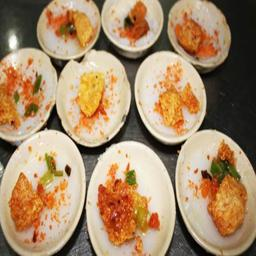

In [56]:
sample = test_data[0]
img    = load_image_from_hf(sample['image_path'])

print(f'Câu hỏi     : {sample["question"]}')
print(f'Ground truth: {sample["answer"]}')
print(f'B2 predict  : {predict_b2(img, sample["question"])}')
display(img)

In [57]:
!pip install -q nltk
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

##  17. Định nghĩa các Metric Đánh giá

| Metric | Mô tả | Đặc điểm |
|---|---|---|
| **Exact Match** | Khớp hoàn toàn với ground truth | Nghiêm ngặt nhất |
| **Soft Accuracy** | Jaccard similarity (giao/hợp tập từ) | Chấp nhận từ đồng nghĩa |
| **BLEU-1** | Precision unigram có smoothing | Phổ biến trong NLP |
| **ROUGE-L** | F1 dựa trên LCS | Tốt cho câu dài |
| **METEOR** | Kết hợp precision, recall, stemming | Tốt hơn BLEU cho tiếng Việt |
| **BERTScore F1** | Tương đồng ngữ nghĩa dùng mBERT | Hiểu nghĩa sâu nhất |

In [81]:
import warnings
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

from nltk.translate.meteor_score import meteor_score as meteor_fn

rouge  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
smooth = SmoothingFunction().method1

def exact_match(pred, gt):
    return float(pred.strip().lower() == gt.strip().lower())

def soft_accuracy(pred, gt):
    p = set(pred.strip().lower().split())
    g = set(gt.strip().lower().split())
    if not p or not g: return 0.0
    return len(p & g) / len(p | g)

def bleu1(pred, gt):
    ref = [gt.strip().lower().split()]
    hyp = pred.strip().lower().split()
    if not hyp: return 0.0
    return sentence_bleu(ref, hyp, weights=(1,0,0,0), smoothing_function=smooth)

def rouge_l(pred, gt):
    return rouge.score(gt, pred)['rougeL'].fmeasure

def meteor(pred, gt):
    ref = gt.strip().lower().split()
    hyp = pred.strip().lower().split()
    if not hyp or not ref: return 0.0
    return meteor_fn([ref], hyp)



def compute_metrics(preds, gts, questions, label=''):
    print(f'\nComputing metrics {label}...')

    em     = [exact_match(p, g)   for p, g in zip(preds, gts)]
    soft   = [soft_accuracy(p, g) for p, g in zip(preds, gts)]
    bleu   = [bleu1(p, g)         for p, g in zip(preds, gts)]
    rougel = [rouge_l(p, g)       for p, g in zip(preds, gts)]
    met    = [meteor(p, g)        for p, g in zip(preds, gts)]

    print('  Computing BERTScore...')
    _, _, F1 = bert_score_fn(
        preds, gts,
        lang='vi',
        model_type='bert-base-multilingual-cased',
        verbose=False,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        batch_size=32,
    )



    return {
        'exact_match'   : round(np.mean(em)              * 100, 2),
        'soft_accuracy' : round(np.mean(soft)             * 100, 2),
        'bleu1'         : round(np.mean(bleu)             * 100, 2),
        'rouge_l'       : round(np.mean(rougel)           * 100, 2),
        'meteor'        : round(np.mean(met)              * 100, 2),
        'bert_score_f1' : round(np.mean(F1.tolist())      * 100, 2),
    }

##  18. Đánh giá B2 trên Tập Test

Chạy đánh giá trên **50 mẫu** test với model đã fine-tune.

In [82]:
import warnings
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

results_b2    = []
questions     = []
qtypes        = []
ground_truths = []

N_EVAL = 50
print(f'Chạy B2 trên {N_EVAL} mẫu...\n')
start = time.time()

for i in tqdm(range(N_EVAL)):
    sample = test_data[i]
    questions.append(sample['question'])
    qtypes.append(sample['question_type'])
    ground_truths.append(sample['answer'])
    try:
        img  = load_image_from_hf(sample['image_path'])
        pred = predict_b2(img, sample['question'])
    except Exception as e:
        print(f'[WARN] sample {i}: {e}')
        pred = ''
    results_b2.append(pred)
    if i % 50 == 0 and i > 0:
        torch.cuda.empty_cache()

elapsed = time.time() - start
print(f'\nDone! {elapsed/60:.1f} phút | {elapsed/N_EVAL:.2f}s/sample')

metrics_b2 = compute_metrics(results_b2, ground_truths, questions, 'B2 PaliGemma Fine-tuned')

print('\n' + '='*45)
print('KẾT QUẢ B2 — PaliGemma')
print('='*45)
for k, v in metrics_b2.items():
    print(f'  {k:<20}: {v:.2f}%')

df_results = pd.DataFrame({
    'Câu hỏi'             : questions,
    'Loại câu hỏi'        : qtypes,
    'Đáp án gốc (GT)'     : ground_truths,
    'Pred B2 (Fine-tuned)': results_b2,
})

df_results.to_csv('B2_paligemma_results.csv', index=False, encoding='utf-8-sig')
print('Đã lưu: B2_paligemma_results.csv')
display(df_results.head(10))

Chạy B2 trên 50 mẫu...



100%|██████████| 50/50 [02:12<00:00,  2.65s/it]



Done! 2.2 phút | 2.65s/sample

Computing metrics B2 PaliGemma Fine-tuned...
  Computing BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


KẾT QUẢ B2 — PaliGemma
  exact_match         : 58.00%
  soft_accuracy       : 65.18%
  bleu1               : 62.04%
  rouge_l             : 71.06%
  meteor              : 40.99%
  bert_score_f1       : 90.21%
Đã lưu: B2_paligemma_results.csv


,Câu hỏi,Loại câu hỏi,Đáp án gốc (GT),Pred B2 (Fine-tuned)
0,trong ảnh là món ăn gì,recognition,bánh bèo,bánh bèo
1,món ăn có màu sắc chủ đạo là gì,attribute,màu sắc chủ đạo là màu trắng,trắng
2,món ăn này có đi kèm nước chấm không,yes/no,không,có
3,đây có phải là món bánh bèo không,yes/no,có,có
4,món ăn được đặt ở đâu,attribute,trong chén,trên bàn
5,món ăn có được bày trên bàn không,yes/no,có,có
6,màu sắc của topping trên món ăn là gì,attribute,màu vàng cam,vàng cam
7,trong ảnh là món gì,recognition,bánh bèo,bánh bèo
8,món ăn này có nước chấm đi kèm không,yes/no,có,có
9,màu sắc chủ đạo của món ăn là màu gì,attribute,màu sắc chủ đạo là màu trắng,trắng


## 19. Đóng gói & Xuất file cho Demo

Đóng gói checkpoint B2 + `model_B.py` thành file `.zip` để tích hợp vào Gradio demo.

| File trong zip | Mô tả |
|---|---|
| `checkpoints/B2/` | LoRA weights + processor |
| `model_B.py` | Script load model & predict |

In [ ]:
import shutil, zipfile, os
from IPython.display import FileLink, display

DOWNLOAD_DIR = '/kaggle/working/demo_B2'
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

# 1. Copy LoRA checkpoint + processor
shutil.copytree(
    f'{WORKING_DIR}/lora_best',
    f'{DOWNLOAD_DIR}/checkpoints/B2',
    dirs_exist_ok=True,
)
print("✓ Copy checkpoints/B2/")

# 2. Copy model_B.py
shutil.copy('/kaggle/working/model_B.py', f'{DOWNLOAD_DIR}/model_B.py')
print("✓ Copy model_B.py")

# 3. Zip lại
ZIP_PATH = '/kaggle/working/demo_B2.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(DOWNLOAD_DIR):
        for file in files:
            full_path = os.path.join(root, file)
            arc_name  = os.path.relpath(full_path, DOWNLOAD_DIR)
            zf.write(full_path, arc_name)

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"\n✓ Đóng gói xong! demo_B2.zip ({size_mb:.1f} MB)")
print("Bấm link bên dưới để tải:")
display(FileLink('demo_B2.zip'))

✓ Copy checkpoints/B2/
✓ Copy model_B.py

✓ Đóng gói xong! demo_B2.zip (30.2 MB)
Bấm link bên dưới để tải:


/kaggle/working/demo_B2.zip